# Space Reliability Index + Explainability

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)

## AnomalyPipeline class (needed to unpickle anomaly_pipeline.joblib)

Extracted from `anomaly_detection.ipynb` so this notebook can load `anomaly_pipeline.joblib` on its own, in a fresh kernel, without depending on `anomaly_detection.ipynb` having been run first in the same session.

In [2]:
from dataclasses import dataclass, field
from typing import List
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


@dataclass
class PipelineConfig:
    id_col: str = "Component_ID"
    lot_col: str = "Batch_ID"
    group_col: str = "Part_Type"
    absolute_result_col: str = "Traditional_Test_Result"
    absolute_fail_value: str = "Fail"
    label_col: str = "Label"
    params: List[str] = field(default_factory=lambda: ["Leakage"])  # Resistance/Vth columns removed from the dataset
    early_timepoints: List[str] = field(default_factory=lambda: ["0h", "24h"])
    weight_lot_relative: float = 0.40
    weight_multivariate: float = 0.40
    weight_drift: float = 0.20
    threshold_monitor: float = 30.0
    threshold_hold: float = 60.0
    threshold_reject: float = 80.0
    z_score_cap: float = 8.0
    iforest_n_estimators: int = 300
    iforest_contamination: str = "auto"
    iforest_min_group_size: int = 30
    random_state: int = 42

    def __post_init__(self):
        total = self.weight_lot_relative + self.weight_multivariate + self.weight_drift
        if abs(total - 1.0) > 1e-6:
            raise ValueError(f"Layer weights must sum to 1.0, got {total:.3f}")
        if not (self.threshold_monitor < self.threshold_hold < self.threshold_reject):
            raise ValueError("Thresholds must be strictly increasing")

    def value_col(self, param, timepoint): return f"{param}_{timepoint}"
    def delta_col(self, param): return f"{param}_delta_24h"
    def pct_change_col(self, param): return f"{param}_pct_change_24h"
    def early_value_cols(self):
        return [self.value_col(p, t) for p in self.params for t in self.early_timepoints]
    def lot_relative_cols(self):
        latest = self.early_timepoints[-1]
        return [self.value_col(p, latest) for p in self.params] + [self.delta_col(p) for p in self.params]
    def multivariate_feature_cols(self):
        cols = []
        for p in self.params:
            cols += [self.value_col(p, t) for t in self.early_timepoints]
            cols += [self.delta_col(p), self.pct_change_col(p)]
        return cols
    def required_input_cols(self):
        # NOTE: absolute_result_col (Traditional_Test_Result) is intentionally NOT required here.
        # It's the ground-truth outcome of the full-duration static-limit check, which by definition
        # doesn't exist yet for a component that's still mid burn-in - that's exactly what a caller
        # is asking this pipeline to help assess early. See AbsoluteSpecLayer below for how it's
        # handled when present (backtest/training data) vs absent (live/new components).
        return [self.id_col, self.lot_col, self.group_col] + self.early_value_cols()


class SchemaError(ValueError): pass

def validate_schema(df, config, require_label=False):
    required = list(config.required_input_cols())
    if require_label: required.append(config.label_col)
    missing = [c for c in required if c not in df.columns]
    if missing: raise SchemaError(f"Input data is missing required columns: {missing}")


class LotMedianImputer:
    def __init__(self, config):
        self.config = config; self.columns = config.early_value_cols()
        self.group_medians_ = {}; self.global_medians_ = {}
    def fit(self, df):
        lot_col = self.config.lot_col
        for col in self.columns:
            self.group_medians_[col] = df.groupby(lot_col)[col].median().to_dict()
            self.global_medians_[col] = float(df[col].median())
        return self
    def transform(self, df):
        df = df.copy(); lot_col = self.config.lot_col
        for col in self.columns:
            if df[col].isna().sum() == 0: continue
            fallback = df[lot_col].map(self.group_medians_[col]).fillna(self.global_medians_[col])
            df[col] = df[col].fillna(fallback)
        return df
    def fit_transform(self, df): return self.fit(df).transform(df)


def add_drift_features(df, config):
    df = df.copy(); first_tp, last_tp = config.early_timepoints[0], config.early_timepoints[-1]
    for p in config.params:
        v_first = df[config.value_col(p, first_tp)]; v_last = df[config.value_col(p, last_tp)]
        df[config.delta_col(p)] = v_last - v_first
        df[config.pct_change_col(p)] = np.where(v_first != 0, (v_last - v_first) / v_first.abs(), 0.0)
    return df


class AbsoluteSpecLayer:
    """Static datasheet-limit check.
    - When Traditional_Test_Result is present in the input (historical/backtest data, where the
      full burn-in already ran) we use that ground truth directly - unchanged behaviour.
    - When it's absent (a genuinely new component, still only at 0h/24h) there is no way to know
      the *final* static-limit verdict yet, so instead we flag anything that has ALREADY breached
      the absolute datasheet limit on the checkpoints we do have. Whether it clears the check later
      is exactly what Module B's drift prediction + this layer's live re-check (once 96h/168h data
      arrives) are for. The limits themselves are learned once from the full historical dataset at
      fit() time (its all-checkpoint max per parameter), so no extra file/config is needed.
    """
    def __init__(self, config): self.config = config; self.limits_ = {}
    def fit(self, df):
        for p in self.config.params:
            cols = [c for c in df.columns if c.startswith(f'{p}_') and c[len(p)+1:].endswith('h')]
            if cols:
                self.limits_[p] = float(df[cols].max().max())
        return self
    def transform(self, df):
        col, fail_value = self.config.absolute_result_col, self.config.absolute_fail_value
        if col in df.columns:
            return (df[col].astype(str).str.strip().str.lower() == fail_value.lower()).astype(int)
        exceeded = pd.Series(False, index=df.index)
        for p in self.config.params:
            limit = self.limits_.get(p)
            if limit is None:
                continue
            for t in self.config.early_timepoints:
                c = self.config.value_col(p, t)
                if c in df.columns:
                    exceeded |= (df[c] >= limit)
        return exceeded.astype(int)


def _robust_median_mad(series):
    median = float(series.median()); mad = float((series - median).abs().median()) * 1.4826
    return median, mad

class LotRelativeScorer:
    def __init__(self, config):
        self.config = config; self.columns = config.lot_relative_cols()
        self.group_stats_ = {}; self.global_stats_ = {}
    def fit(self, df):
        lot_col = self.config.lot_col
        for col in self.columns:
            self.group_stats_[col] = df.groupby(lot_col)[col].apply(_robust_median_mad).to_dict()
            self.global_stats_[col] = _robust_median_mad(df[col])
        return self
    def transform(self, df):
        lot_col = self.config.lot_col
        abs_z_frame = pd.DataFrame(index=df.index)
        for col in self.columns:
            medians = df[lot_col].map(lambda lot: self.group_stats_[col].get(lot, (np.nan, np.nan))[0])
            mads = df[lot_col].map(lambda lot: self.group_stats_[col].get(lot, (np.nan, np.nan))[1])
            g_med, g_mad = self.global_stats_[col]
            medians = medians.fillna(g_med)
            mads = mads.fillna(g_mad).replace(0, g_mad if g_mad > 0 else 1e-6)
            abs_z_frame[col] = ((df[col] - medians) / mads).abs()
        worst_z = abs_z_frame.max(axis=1)
        score = (worst_z.clip(upper=self.config.z_score_cap) / self.config.z_score_cap) * 100
        return score, worst_z


GLOBAL_KEY = "__global__"
class MultivariateAnomalyScorer:
    def __init__(self, config):
        self.config = config; self.feature_cols = config.multivariate_feature_cols()
        self.models_ = {}; self.score_bounds_ = {}
        self.background_ = {}   # per-group background sample, stored at fit time, for SHAP later

    def _fit_one(self, X):
        pipeline = Pipeline([("scaler", StandardScaler()),
                              ("iforest", IsolationForest(n_estimators=self.config.iforest_n_estimators,
                                                           contamination=self.config.iforest_contamination,
                                                           random_state=self.config.random_state))])
        pipeline.fit(X)
        raw = -pipeline.decision_function(X)
        p1, p99 = np.percentile(raw, [1, 99])
        return pipeline, (float(p1), float(p99))

    def fit(self, df):
        group_col = self.config.group_col
        n_bg = min(100, len(df))
        model, bounds = self._fit_one(df[self.feature_cols].values)
        self.models_[GLOBAL_KEY] = model; self.score_bounds_[GLOBAL_KEY] = bounds
        self.background_[GLOBAL_KEY] = df[self.feature_cols].sample(n_bg, random_state=self.config.random_state)
        for group_value, group_df in df.groupby(group_col):
            if len(group_df) < self.config.iforest_min_group_size:
                print(f"WARNING: group '{group_value}' has only {len(group_df)} rows; using global fallback")
                continue
            model, bounds = self._fit_one(group_df[self.feature_cols].values)
            self.models_[str(group_value)] = model; self.score_bounds_[str(group_value)] = bounds
            n_bg_g = min(100, len(group_df))
            self.background_[str(group_value)] = group_df[self.feature_cols].sample(n_bg_g, random_state=self.config.random_state)
        return self

    def transform(self, df):
        group_col = self.config.group_col
        scores = pd.Series(index=df.index, dtype=float)
        for group_value, group_df in df.groupby(group_col):
            key = str(group_value) if str(group_value) in self.models_ else GLOBAL_KEY
            model = self.models_[key]; p1, p99 = self.score_bounds_[key]
            raw = -model.decision_function(group_df[self.feature_cols].values)
            norm = np.clip((raw - p1) / (p99 - p1 + 1e-9), 0, 1) * 100
            scores.loc[group_df.index] = norm
        return scores

    def shap_top_features(self, df, top_k=3):
        group_col = self.config.group_col
        out = pd.Series(index=df.index, dtype=object)
        for group_value, group_df in df.groupby(group_col):
            key = str(group_value) if str(group_value) in self.models_ else GLOBAL_KEY
            model = self.models_[key]
            background = self.background_[key]
            score_fn = lambda X, _m=model: -_m.decision_function(X)
            explainer = shap.Explainer(score_fn, background.values, feature_names=self.feature_cols)
            sv = explainer(group_df[self.feature_cols].values)
            for i, idx in enumerate(group_df.index):
                vals = np.asarray(sv.values[i]).reshape(-1)
                order = np.argsort(-np.abs(vals))[:top_k]
                out.loc[idx] = ', '.join(f'{self.feature_cols[j]}({vals[j]:+.2f})' for j in order)
        return out


class DriftSeverityScorer:
    def __init__(self, config): self.config = config; self.bound_ = None
    def _severity(self, df):
        cols = [self.config.pct_change_col(p) for p in self.config.params]
        return df[cols].abs().max(axis=1)
    def fit(self, df):
        bound = float(self._severity(df).quantile(0.99)); self.bound_ = bound if bound > 0 else 1e-6
        return self
    def transform(self, df):
        return (self._severity(df).clip(upper=self.bound_) / self.bound_) * 100


def combine(lot_score, mv_score, drift_score, absolute_fail, config):
    combined = (config.weight_lot_relative*lot_score + config.weight_multivariate*mv_score + config.weight_drift*drift_score)
    combined = np.where(absolute_fail == 1, np.maximum(combined, config.threshold_reject + 5), combined)
    return pd.Series(np.round(np.clip(combined, 0, 100), 1), index=lot_score.index)


def decide(risk_score, config):
    bins = [-np.inf, config.threshold_monitor, config.threshold_hold, config.threshold_reject, np.inf]
    return pd.cut(risk_score, bins=bins, labels=["PASS", "MONITOR", "HOLD", "REJECT"], right=False).astype(str)


class AnomalyPipeline:
    def __init__(self, config=None):
        self.config = config or PipelineConfig()
        self.imputer = LotMedianImputer(self.config)
        self.lot_scorer = LotRelativeScorer(self.config)
        self.mv_scorer = MultivariateAnomalyScorer(self.config)
        self.drift_scorer = DriftSeverityScorer(self.config)
        self.absolute_layer = AbsoluteSpecLayer(self.config)

    def fit(self, df):
        validate_schema(df, self.config)
        df = self.imputer.fit_transform(df); df = add_drift_features(df, self.config)
        self.lot_scorer.fit(df); self.mv_scorer.fit(df); self.drift_scorer.fit(df)
        self.absolute_layer.fit(df)  # learns per-param datasheet limits, for live/new-data scoring
        return self

    def predict(self, df):
        validate_schema(df, self.config)
        original_index = df.index
        df = self.imputer.transform(df); df = add_drift_features(df, self.config)
        absolute_fail = self.absolute_layer.transform(df)
        lot_score, worst_z = self.lot_scorer.transform(df)
        mv_score = self.mv_scorer.transform(df)
        drift_score = self.drift_scorer.transform(df)
        risk_score = combine(lot_score, mv_score, drift_score, absolute_fail, self.config)
        decision = decide(risk_score, self.config)
        result = pd.DataFrame({
            self.config.id_col: df[self.config.id_col], self.config.lot_col: df[self.config.lot_col],
            self.config.group_col: df[self.config.group_col], "Absolute_Spec_Fail": absolute_fail,
            "Lot_Relative_Score": lot_score.round(1), "Worst_Lot_Zscore": worst_z.round(2),
            "Multivariate_Score": mv_score.round(1), "Drift_Score": drift_score.round(1),
            "Anomaly_Risk_Score": risk_score, "QA_Decision": decision,
        }, index=original_index)
        # Always emit the same columns whether or not ground truth exists yet, so downstream
        # code (frontend/backend) never has to branch on which columns are present.
        result[self.config.label_col] = df[self.config.label_col] if self.config.label_col in df.columns else pd.NA
        result[self.config.absolute_result_col] = df[self.config.absolute_result_col] if self.config.absolute_result_col in df.columns else pd.NA
        result['Absolute_Check_Source'] = 'ground_truth' if self.config.absolute_result_col in df.columns else 'proxy_live'
        return result


## Configurations

In [3]:
RAW_CSV_PATH = "burn_in_dataset.csv"
ANOMALY_RESULTS_PATH = "anomaly_results.csv"
ANOMALY_SHAP_BUNDLE_PATH = "anomaly_shap_bundle.joblib"
DRIFT_MODEL_PATH = "drift_prediction_models.joblib"
SPLIT_PATH = "component_split.csv"

METRICS = ['Leakage']  # Resistance/Vth columns removed from the dataset
CHECKPOINTS = ['0h', '24h', '96h', '168h']

ABSOLUTE_FAIL_RISK_FLOOR = 65.0

SLOPE_REJECT_RISK_FLOOR = 65.0

TARGET_RECALL = 0.98

## Load everything

In [4]:
df = pd.read_csv(RAW_CSV_PATH)
anomaly = pd.read_csv(ANOMALY_RESULTS_PATH)
bundle = joblib.load(DRIFT_MODEL_PATH)
anomaly_shap_bundle = joblib.load(ANOMALY_SHAP_BUNDLE_PATH)
split = pd.read_csv(SPLIT_PATH)

print(df.shape, 'raw rows')
print(anomaly.shape, 'anomaly results rows')

missing_from_raw = set(anomaly['Component_ID']) - set(df['Component_ID'])
missing_from_anomaly = set(df['Component_ID']) - set(anomaly['Component_ID'])
print(f'{len(missing_from_raw)} anomaly rows have no match in raw data; '
      f'{len(missing_from_anomaly)} raw rows have no match in anomaly results')

if 'safety_slope' not in bundle:
    raise KeyError("drift_prediction_models.joblib has no 'safety_slope' key - re-run the v5.1 "
                    "drift-prediction notebook first so both modules share the same thresholds.")
safety_slope = bundle['safety_slope']
anomaly.head()

(10000, 17) raw rows
(10000, 15) anomaly results rows
0 anomaly rows have no match in raw data; 0 raw rows have no match in anomaly results


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result,Absolute_Check_Source,split,SHAP_Top_Anomaly_Features
0,C504,ISRO-SCL-250106-01,MOSFET,0,7.5,0.60,14.8,22.8,19.5,HOLD,Safe,Pass,ground_truth,train,NaN
1,C505,ISRO-SCL-250224-08,Digital Logic IC,0,12.1,0.96,19.2,24.2,21.9,HOLD,Safe,Pass,ground_truth,train,NaN
2,C507,ISRO-SCL-250224-08,Digital Logic IC,0,15.6,1.25,32.9,7.3,14.1,PASS,Safe,Pass,ground_truth,train,NaN
3,C509,ISRO-SCL-250113-02,MOSFET,0,4.2,0.33,0.2,7.6,5.6,PASS,Safe,Pass,ground_truth,train,NaN
4,C510,ISRO-SCL-250113-02,MOSFET,0,6.4,0.51,3.1,14.0,10.7,PASS,Safe,Pass,ground_truth,train,NaN


## Re-run Module B's feature pipeline

In [5]:
feature_cols_raw = bundle['feature_cols_raw']

# Only clean checkpoints that actually exist in this input - a component still mid burn-in
# genuinely won't have 96h/168h columns at all, not just blank values in them.
reading_cols = [f'{m}_{cp}' for m in METRICS for cp in CHECKPOINTS if f'{m}_{cp}' in df.columns]
for col in reading_cols:
    df.loc[df[col] < 0, col] = np.nan

present_checkpoints = [cp for cp in CHECKPOINTS if f'Timestamp_{cp}' in df.columns]
for cp in present_checkpoints:
    df[f'Timestamp_{cp}'] = pd.to_datetime(df[f'Timestamp_{cp}'], format='ISO8601')
df['elapsed_24h'] = (df['Timestamp_24h'] - df['Timestamp_0h']).dt.total_seconds() / 3600

if 'Timestamp_168h' in df.columns:
    # historical/backtest data - the burn-in already ran, use the real elapsed time
    df['elapsed_168h'] = (df['Timestamp_168h'] - df['Timestamp_0h']).dt.total_seconds() / 3600
else:
    # live data - 168h hasn't happened yet, that's what we're predicting. Use the planned
    # burn-in duration (learned from history and saved by drift_prediction.ipynb) instead.
    df['elapsed_168h'] = bundle.get('nominal_elapsed_168h', 168.0)
    print(f"No Timestamp_168h in input - using nominal elapsed_168h = {df['elapsed_168h'].iloc[0]:.2f}h "
          "(this is expected for components still mid burn-in)")

df.loc[:, feature_cols_raw] = bundle['imputer'].transform(df[feature_cols_raw])

df['Leakage_slope'] = (df['Leakage_24h'] - df['Leakage_0h']) / df['elapsed_24h']

feature_cols_num = feature_cols_raw + ['Stress_Level', 'elapsed_24h', 'Leakage_slope']
X = pd.get_dummies(df[feature_cols_num + ['Proxy_Stress', 'Part_Type']], columns=['Proxy_Stress', 'Part_Type'])
X = X.reindex(columns=bundle['feature_columns'], fill_value=0)
X.shape

(10000, 12)

In [6]:
rf_pred = bundle['rf'].predict(X)
gb_pred = bundle['gb'].predict(X)
stacked_raw = bundle['meta_model'].predict(np.hstack([rf_pred, gb_pred]))
lower_raw = bundle['quantile_lower'].predict(X)
upper_raw = bundle['quantile_upper'].predict(X)

lower_raw, upper_raw = np.minimum(lower_raw, upper_raw), np.maximum(lower_raw, upper_raw)

def reconstruct(raw):
    out = pd.DataFrame(index=df.index)
    out['Leakage_168h'] = np.expm1(raw[:, 1])
    return out

point, lower, upper = reconstruct(stacked_raw), reconstruct(lower_raw), reconstruct(upper_raw)
rf_point, gb_point = reconstruct(rf_pred), reconstruct(gb_pred)

df['Pred_Leakage_168h'] = point['Leakage_168h']
df['Interval_Width_Leakage'] = (upper['Leakage_168h'] - lower['Leakage_168h']).clip(lower=0)

# RF-vs-GB disagreement
df['Disagreement_Leakage'] = (rf_point['Leakage_168h'] - gb_point['Leakage_168h']).abs()

df[['Pred_Leakage_168h']].describe()

,Pred_Leakage_168h
count,10000.000000
mean,1.263209
std,0.851844
min,0.184479
25%,0.676830
50%,1.097101
75%,1.569192
max,5.036779


## Turn predictions into three 0-100 scores

In [7]:
# `split` only covers historical Component_IDs (train/val/test). Genuinely new components
# won't be in it - left-join and treat anything unmatched as 'live' rather than erroring out.
df = df.merge(split[['Component_ID','split']], on='Component_ID', how='left')
df['split'] = df['split'].fillna('live')
fit_mask = df['split'].isin(['train','val'])   # normalization bounds never see `test` or `live`
if not fit_mask.any():
    # scoring a live-only batch in isolation: fall back to bounds saved during the last full
    # training run (reliability_bundle.joblib) instead of fitting quantiles on a handful of
    # brand-new rows, which would be statistically meaningless.
    import os
    if os.path.exists('reliability_bundle.joblib'):
        _rb = joblib.load('reliability_bundle.joblib')
        fit_mask = df['Component_ID'].isin(_rb.get('fit_component_ids', []))
    if not fit_mask.any():
        fit_mask = pd.Series(True, index=df.index)  # last resort: nothing to anchor to

pred_leak_drift = ((df['Pred_Leakage_168h'] - df['Leakage_24h']) / df['Leakage_24h'].abs()).abs()

df['Predicted_Drift_Leakage'] = pred_leak_drift
df['Predicted_Drift_Severity_raw'] = pred_leak_drift

bound = df.loc[fit_mask, 'Predicted_Drift_Severity_raw'].quantile(0.99)
df['Predicted_Drift_Score'] = (df['Predicted_Drift_Severity_raw'].clip(upper=bound) / max(bound, 1e-9) * 100).clip(0, 100)

iw = df[['Interval_Width_Leakage']]
iw_bounds = iw[fit_mask].quantile(0.99).clip(lower=1e-9)
aleatoric = ((iw / iw_bounds).clip(upper=1.5).max(axis=1) * 100).clip(0, 100)

dis = df[['Disagreement_Leakage']]
dis_bounds = dis[fit_mask].quantile(0.99).clip(lower=1e-9)
epistemic = ((dis / dis_bounds).clip(upper=1.5).max(axis=1) * 100).clip(0, 100)

df['Uncertainty_Score'] = (0.6 * aleatoric + 0.4 * epistemic).clip(0, 100).round(1)

def _drift_rate(v24, v168, elapsed24, elapsed168):
    return (v168 - v24) / (elapsed168 - elapsed24)

slope_flag = pd.Series(False, index=df.index)
for m in METRICS:
    rate = _drift_rate(df[f'{m}_24h'], df[f'Pred_{m}_168h'], df['elapsed_24h'], df['elapsed_168h']).abs()
    slope_flag |= (rate > safety_slope[m])
df['Slope_Reject_Flag'] = slope_flag

df[['Predicted_Drift_Score', 'Uncertainty_Score']].describe()

,Predicted_Drift_Score,Uncertainty_Score
count,10000.000000,10000.000000
mean,33.092439,26.461080
std,18.486098,16.315319
min,0.258800,6.100000
25%,19.926140,14.100000
50%,29.093541,21.000000
75%,41.273619,35.200000
max,100.000000,100.000000


## Combine with Module A

In [8]:
merged = anomaly.merge(
    df[['Component_ID', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Proxy_Stress', 'Slope_Reject_Flag',
        'Predicted_Drift_Leakage', 'Leakage_0h', 'Leakage_24h']],
    on='Component_ID', how='inner',
)
print(f'{len(merged)} components matched between the two modules')
merged.head()

10000 components matched between the two modules


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result,Absolute_Check_Source,split,SHAP_Top_Anomaly_Features,Predicted_Drift_Score,Uncertainty_Score,Proxy_Stress,Slope_Reject_Flag,Predicted_Drift_Leakage,Leakage_0h,Leakage_24h
0,C504,ISRO-SCL-250106-01,MOSFET,0,7.5,0.60,14.8,22.8,19.5,HOLD,Safe,Pass,ground_truth,train,NaN,50.408358,24.6,Cycling-Medium,False,1.259190,0.240,0.354
1,C505,ISRO-SCL-250224-08,Digital Logic IC,0,12.1,0.96,19.2,24.2,21.9,HOLD,Safe,Pass,ground_truth,train,NaN,36.910133,12.7,Thermal-High,False,0.922007,0.125,0.188
2,C507,ISRO-SCL-250224-08,Digital Logic IC,0,15.6,1.25,32.9,7.3,14.1,PASS,Safe,Pass,ground_truth,train,NaN,18.331170,14.1,Cycling-Medium,False,0.457909,0.934,1.075
3,C509,ISRO-SCL-250113-02,MOSFET,0,4.2,0.33,0.2,7.6,5.6,PASS,Safe,Pass,ground_truth,train,NaN,17.036151,26.8,Radiation-Low,False,0.425559,0.636,0.737
4,C510,ISRO-SCL-250113-02,MOSFET,0,6.4,0.51,3.1,14.0,10.7,PASS,Safe,Pass,ground_truth,train,NaN,25.881814,20.1,Thermal-High,False,0.646522,0.315,0.407


## Tune weights + tier boundaries on `val` for a target RECALL, not just AUC


In [9]:
val_mask = merged['split'] == 'val'
label_val = merged.loc[val_mask, 'Label'].values
anomaly_v = merged.loc[val_mask, 'Anomaly_Risk_Score'].values
drift_v = merged.loc[val_mask, 'Predicted_Drift_Score'].values
unc_v = merged.loc[val_mask, 'Uncertainty_Score'].values
absfail_v = merged.loc[val_mask, 'Absolute_Spec_Fail'].values
slopeflag_v = merged.loc[val_mask, 'Slope_Reject_Flag'].values

def _floor(combined):
    combined = np.where(absfail_v == 1, np.maximum(combined, ABSOLUTE_FAIL_RISK_FLOOR), combined)
    combined = np.where(slopeflag_v, np.maximum(combined, SLOPE_REJECT_RISK_FLOOR), combined)
    return combined

def threshold_for_recall(combined, label, target_recall):
    fail_mask = (label == 'Fail')
    n_fail = int(fail_mask.sum())
    if n_fail == 0:
        return None
    order = np.argsort(-combined)
    caught = 0
    for idx in order:
        if fail_mask[idx]:
            caught += 1
        if caught / n_fail >= target_recall:
            thr = combined[idx]
            flagged = combined >= thr
            recall = float((flagged & fail_mask).sum()) / n_fail
            safe_mask = (label == 'Safe')
            fa = float((flagged & safe_mask).sum()) / max(int(safe_mask.sum()), 1)
            return float(thr), recall, fa
    return None

rng = np.random.RandomState(0)
best = None
for _ in range(500):
    w = rng.dirichlet([2, 2, 1])
    combined = _floor(w[0]*anomaly_v + w[1]*drift_v + w[2]*unc_v)
    result = threshold_for_recall(combined, label_val, TARGET_RECALL)
    if result is None:
        continue
    thr_borderline, recall, fa = result
    auc = roc_auc_score((label_val == 'Fail').astype(int), combined)
    key = (fa, -auc)
    if best is None or key < best[0]:
        best = (key, w, thr_borderline, recall, fa, auc)

if best is None:
    raise RuntimeError(
        f'No weight combination reached {TARGET_RECALL:.0%} recall on val Fail cases - '
        'lower TARGET_RECALL or revisit the upstream signals before shipping this tier.'
    )

_, best_w, thr_borderline, achieved_recall, achieved_fa, best_auc = best
tot = best_w.sum()
WEIGHT_ANOMALY, WEIGHT_PREDICTED_DRIFT, WEIGHT_UNCERTAINTY = [round(float(x/tot), 3) for x in best_w]
print('tuned weights -> anomaly:', WEIGHT_ANOMALY, ' drift:', WEIGHT_PREDICTED_DRIFT, ' uncertainty:', WEIGHT_UNCERTAINTY)
print(f'-> {achieved_recall:.1%} recall on val Fail via Borderline/High-Risk, at {achieved_fa:.1%} false-alarm rate '
      f'(AUC={best_auc:.4f}, reported for context only)')

combined_v = _floor(WEIGHT_ANOMALY*anomaly_v + WEIGHT_PREDICTED_DRIFT*drift_v + WEIGHT_UNCERTAINTY*unc_v)
safe_scores_v = combined_v[label_val == 'Safe']
RISK_SAFE_MAX = min(round(float(np.percentile(safe_scores_v, 80)), 1), round(thr_borderline - 0.1, 1))
RISK_BORDERLINE_MAX = max(round(float(np.percentile(safe_scores_v, 95)), 1), round(thr_borderline, 1))
print('tuned tier boundaries -> Safe <', RISK_SAFE_MAX, ' Borderline <', RISK_BORDERLINE_MAX)
print(f'NOTE: Borderline cut is anchored to the {TARGET_RECALL:.0%}-recall threshold on val; Safe cut is the')
print('80th percentile of val Safe scores (softer early-warning tier), clipped below the recall anchor.')

tuned weights -> anomaly: 0.948  drift: 0.038  uncertainty: 0.014
-> 98.0% recall on val Fail via Borderline/High-Risk, at 15.5% false-alarm rate (AUC=0.9278, reported for context only)
tuned tier boundaries -> Safe < 14.5  Borderline < 28.0
NOTE: Borderline cut is anchored to the 98%-recall threshold on val; Safe cut is the
80th percentile of val Safe scores (softer early-warning tier), clipped below the recall anchor.


In [10]:
merged['Space_Risk_Score'] = (
    WEIGHT_ANOMALY * merged['Anomaly_Risk_Score']
    + WEIGHT_PREDICTED_DRIFT * merged['Predicted_Drift_Score']
    + WEIGHT_UNCERTAINTY * merged['Uncertainty_Score']
)
merged['Space_Risk_Score'] = np.where(
    merged['Absolute_Spec_Fail'] == 1,
    np.maximum(merged['Space_Risk_Score'], ABSOLUTE_FAIL_RISK_FLOOR),
    merged['Space_Risk_Score'],
)
merged['Space_Risk_Score'] = np.where(
    merged['Slope_Reject_Flag'],
    np.maximum(merged['Space_Risk_Score'], SLOPE_REJECT_RISK_FLOOR),
    merged['Space_Risk_Score'],
)
merged['Space_Risk_Score'] = merged['Space_Risk_Score'].clip(0, 100).round(1)
merged['Space_Reliability_Index'] = (100 - merged['Space_Risk_Score']).round(1)

def tier(score):
    if score < RISK_SAFE_MAX: return 'Space-Safe'
    if score < RISK_BORDERLINE_MAX: return 'Borderline'
    return 'High-Risk'

merged['Reliability_Tier'] = merged['Space_Risk_Score'].apply(tier)
merged['Reliability_Tier'].value_counts()

,count
Reliability_Tier,
Space-Safe,5594
High-Risk,2309
Borderline,2097


In [11]:
# Persist everything a later, standalone live-scoring run needs, so those runs don't have to
# recompute quantile bounds / tuned weights / tier cuts on whatever small batch they're given.
joblib.dump({
    'weight_anomaly': WEIGHT_ANOMALY, 'weight_predicted_drift': WEIGHT_PREDICTED_DRIFT,
    'weight_uncertainty': WEIGHT_UNCERTAINTY,
    'risk_safe_max': RISK_SAFE_MAX, 'risk_borderline_max': RISK_BORDERLINE_MAX,
    'absolute_fail_risk_floor': ABSOLUTE_FAIL_RISK_FLOOR, 'slope_reject_risk_floor': SLOPE_REJECT_RISK_FLOOR,
    'drift_score_bound': float(bound), 'iw_bounds': iw_bounds.to_dict(), 'dis_bounds': dis_bounds.to_dict(),
    'fit_component_ids': df.loc[fit_mask, 'Component_ID'].tolist(),
}, 'reliability_bundle.joblib')
print('saved reliability_bundle.joblib')


saved reliability_bundle.joblib


## Validation against Label


In [12]:
for split_name in [s for s in ['train', 'test'] if (merged['split'] == s).any()]:
    subset = merged[merged['split'] == split_name]
    print(f'=== {split_name.upper()} ({"in-sample, reference only" if split_name=="train" else "held-out, trust this one"}) ===')
    print(pd.crosstab(subset['Reliability_Tier'], subset['Label']))
    fail_mask = subset['Label'] == 'Fail'
    safe_mask = subset['Label'] == 'Safe'
    caught_any = subset.loc[fail_mask, 'Reliability_Tier'].isin(['Borderline', 'High-Risk']).mean()
    caught_hr = subset.loc[fail_mask, 'Reliability_Tier'].eq('High-Risk').mean()
    false_alarm = subset.loc[safe_mask, 'Reliability_Tier'].isin(['Borderline', 'High-Risk']).mean()
    print(f'Recall on true FAIL, Borderline+High-Risk: {caught_any:.1%}')
    print(f'Recall on true FAIL, High-Risk only:       {caught_hr:.1%}')
    print(f'False-alarm rate on true SAFE:              {false_alarm:.1%}')
    print()

=== TRAIN (in-sample, reference only) ===
Label             Borderline  Fail  Safe
Reliability_Tier                        
Borderline               549    48   654
High-Risk                521   610   157
Space-Safe               150    35  3085
Recall on true FAIL, Borderline+High-Risk: 94.9%
Recall on true FAIL, High-Risk only:       88.0%
False-alarm rate on true SAFE:              20.8%

=== TEST (held-out, trust this one) ===
Label             Borderline  Fail  Safe
Reliability_Tier                        
Borderline               172    18   252
High-Risk                196   235    76
Space-Safe                47     6  1234
Recall on true FAIL, Borderline+High-Risk: 97.7%
Recall on true FAIL, High-Risk only:       90.7%
False-alarm rate on true SAFE:              21.0%



## Explainability

In [13]:
GLOBAL_KEY = '__global__'

def _impute_for_anomaly_shap(frame):
    '''Replicates Module A's LotMedianImputer.transform using its exported plain dicts - no
    custom-class instance required, so this works regardless of which process fit the original.'''
    frame = frame.copy()
    lot_col = anomaly_shap_bundle['lot_col']
    for col in anomaly_shap_bundle['early_value_cols']:
        if frame[col].isna().sum() == 0:
            continue
        group_medians = anomaly_shap_bundle['group_medians'][col]
        fallback = frame[lot_col].map(group_medians).fillna(anomaly_shap_bundle['global_medians'][col])
        frame[col] = frame[col].fillna(fallback)
    return frame

def _add_drift_features_for_shap(frame):
    '''Replicates Module A's add_drift_features() using the exported params/early_timepoints - same
    column names (`{param}_delta_24h`, `{param}_pct_change_24h`) the fitted IsolationForests expect.'''
    frame = frame.copy()
    first_tp = anomaly_shap_bundle['early_timepoints'][0]
    last_tp = anomaly_shap_bundle['early_timepoints'][-1]
    for p in anomaly_shap_bundle['params']:
        v_first = frame[f'{p}_{first_tp}']; v_last = frame[f'{p}_{last_tp}']
        frame[f'{p}_delta_{last_tp}'] = v_last - v_first
        frame[f'{p}_pct_change_{last_tp}'] = np.where(v_first != 0, (v_last - v_first) / v_first.abs(), 0.0)
    return frame

def anomaly_shap_top_features(frame, top_k=2):
    '''Standalone equivalent of Module A's MultivariateAnomalyScorer.shap_top_features(), operating
    on the plain anomaly_shap_bundle dict instead of a loaded class instance.'''
    feature_cols = anomaly_shap_bundle['feature_cols']
    group_col = anomaly_shap_bundle['group_col']
    models = anomaly_shap_bundle['iforest_models']
    backgrounds = anomaly_shap_bundle['background']
    out = pd.Series(index=frame.index, dtype=object)
    for group_value, group_df in frame.groupby(group_col):
        key = str(group_value) if str(group_value) in models else GLOBAL_KEY
        model = models[key]
        background = backgrounds[key]
        score_fn = lambda Xg, _m=model: -_m.decision_function(Xg)
        explainer = shap.Explainer(score_fn, background[feature_cols].values, feature_names=feature_cols)
        sv = explainer(group_df[feature_cols].values)
        for i, idx in enumerate(group_df.index):
            vals = np.asarray(sv.values[i]).reshape(-1)
            order = np.argsort(-np.abs(vals))[:top_k]
            out.loc[idx] = ', '.join(f'{feature_cols[j]}({vals[j]:+.2f})' for j in order)
    return out

rf_explainer = shap.TreeExplainer(bundle['rf'])
TARGET_ORDER = ['Leakage_96h_log', 'Leakage_168h_log']
TARGET_IDX_168H = {'Leakage': 1}

def dominant_metric_row(row):
    '''Only Leakage is modeled now, so it's always the dominant metric - kept as a function so
    the rest of the explainability code below doesn't need to change if a metric is added back.'''
    return 'Leakage'

id_to_dfidx = pd.Series(df.index.values, index=df['Component_ID']).to_dict()
print('SHAP explainability helpers ready')

SHAP explainability helpers ready


In [14]:
np.random.seed(0)
test_mask_m = merged['split'] == 'test'
needs_explanation = merged[test_mask_m & merged['Reliability_Tier'].isin(['Borderline', 'High-Risk'])].copy()
safe_pool = merged[test_mask_m & (merged['Reliability_Tier'] == 'Space-Safe')]
safe_sample = safe_pool.sample(min(15, len(safe_pool)), random_state=0)
to_explain = pd.concat([needs_explanation, safe_sample])
explain_ids = to_explain['Component_ID'].tolist()
print(f'computing SHAP explanations for {len(explain_ids)} components '
      f'({len(needs_explanation)} Borderline/High-Risk + {len(safe_sample)} Space-Safe sample)')

# --- 1) Drift SHAP (batched, one call per unique dominant metric group) ---
dfidx = [id_to_dfidx[c] for c in explain_ids]
sub_scores = merged.set_index('Component_ID').loc[explain_ids]
dominant = sub_scores.apply(dominant_metric_row, axis=1)

drift_text = {}
feat_names = list(X.columns)
for metric in ['Leakage']:
    ids_this_metric = [cid for cid, m in dominant.items() if m == metric]
    if not ids_this_metric:
        continue
    rows = [id_to_dfidx[c] for c in ids_this_metric]
    sv = rf_explainer(X.loc[rows])
    out_idx = TARGET_IDX_168H[metric]
    vals_all = np.asarray(sv.values)[:, :, out_idx]
    for pos, cid in enumerate(ids_this_metric):
        vals = vals_all[pos]
        order = np.argsort(-np.abs(vals))[:2]
        drift_text[cid] = (metric, ', '.join(f'{feat_names[j]}({vals[j]:+.3f})' for j in order))

# --- 2) Anomaly SHAP (reuse Module A's exported bundle, no custom classes involved) ---
raw_needed_cols = anomaly_shap_bundle['early_value_cols'] + [
    anomaly_shap_bundle['lot_col'], anomaly_shap_bundle['group_col'], 'Component_ID']
dfx_shap = df[df['Component_ID'].isin(explain_ids)][raw_needed_cols].copy()
dfx_shap = _impute_for_anomaly_shap(dfx_shap)
dfx_shap = _add_drift_features_for_shap(dfx_shap)
anomaly_series = anomaly_shap_top_features(dfx_shap.set_index('Component_ID'), top_k=2)
anomaly_text = anomaly_series.to_dict()

# --- 3) Compose the final QA-facing narrative from the two SHAP results + factual annotations ---
def compose_explanation(row):
    cid = row['Component_ID']
    parts = [f"{row['Reliability_Tier']}."]
    if cid in drift_text:
        metric, feats = drift_text[cid]
        parts.append(f'[SHAP] Predicted {metric} 168h drift driven mainly by {feats}.')
    if anomaly_text.get(cid):
        parts.append(f"[SHAP] Anomaly score driven mainly by {anomaly_text[cid]}.")
    if row['Absolute_Spec_Fail'] == 1:
        parts.append('Failed traditional fixed-limit spec check.')
    if row['Worst_Lot_Zscore'] >= 2.0:
        parts.append(f"Batch-relative outlier (z={row['Worst_Lot_Zscore']:.2f} vs its own lot).")
    if row['Slope_Reject_Flag']:
        parts.append('Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection.')
    if row['Uncertainty_Score'] >= 60:
        parts.append('Forecast confidence is low (wide interval and/or RF/GB disagreement) - recommend extended monitoring rather than trusting the point estimate.')
    return ' '.join(parts)

merged['Explainability_Reason'] = pd.NA
computed_mask = merged['Component_ID'].isin(explain_ids)
merged.loc[computed_mask, 'Explainability_Reason'] = merged.loc[computed_mask].apply(compose_explanation, axis=1)
merged.loc[~computed_mask, 'Explainability_Reason'] = (
    'Not computed - SHAP explanations are bounded to Borderline/High-Risk TEST components plus a Space-Safe sample.'
)
print('done')

computing SHAP explanations for 964 components (949 Borderline/High-Risk + 15 Space-Safe sample)


ExactExplainer explainer: 354it [00:38,  8.45it/s]
ExactExplainer explainer: 134it [00:11,  1.58it/s]                         
ExactExplainer explainer: 479it [00:40,  8.90it/s]


done


In [15]:
print('=== sample High-Risk explanations (TEST split) ===\n')
for _, row in merged[(merged['Reliability_Tier'] == 'High-Risk') & (merged['split'] == 'test')].head(5).iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample High-Risk explanations (TEST split) ===

C554 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_24h(+0.395), Leakage_slope(+0.287). [SHAP] Anomaly score driven mainly by Leakage_delta_24h(+0.04), Leakage_pct_change_24h(+0.02). Batch-relative outlier (z=4.21 vs its own lot). Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection.

C558 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_24h(+0.438), Leakage_slope(+0.381). [SHAP] Anomaly score driven mainly by Leakage_pct_change_24h(+0.08), Leakage_delta_24h(+0.06). Batch-relative outlier (z=5.42 vs its own lot). Predicted 168h drift rate exceeds the Safe-population safety slope - flagged for early rejection. Forecast confidence is low (wide interval and/or RF/GB disagreement) - recommend extended monitoring rather than trusting the point estimate.

C569 - High-Risk. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_24h(-0.264), 

In [16]:
print('=== sample Space-Safe explanations, for contrast (TEST split) ===\n')
safe_shown = merged[(merged['Reliability_Tier'] == 'Space-Safe') & (merged['split'] == 'test')
                     & (merged['Component_ID'].isin(explain_ids))].head(3)
for _, row in safe_shown.iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample Space-Safe explanations, for contrast (TEST split) ===

C2003 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_slope(-0.122), Leakage_0h(-0.008). [SHAP] Anomaly score driven mainly by Leakage_0h(-0.01), Leakage_delta_24h(-0.01).

C2128 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_24h(+0.145), Leakage_slope(-0.125). [SHAP] Anomaly score driven mainly by Leakage_pct_change_24h(-0.02), Leakage_delta_24h(-0.01).

C2276 - Space-Safe. [SHAP] Predicted Leakage 168h drift driven mainly by Leakage_24h(-0.046), Leakage_slope(-0.020). [SHAP] Anomaly score driven mainly by Leakage_delta_24h(-0.01), Leakage_24h(-0.01).



## Quick look: score distribution (TEST split, so the plot matches the honest metrics above)

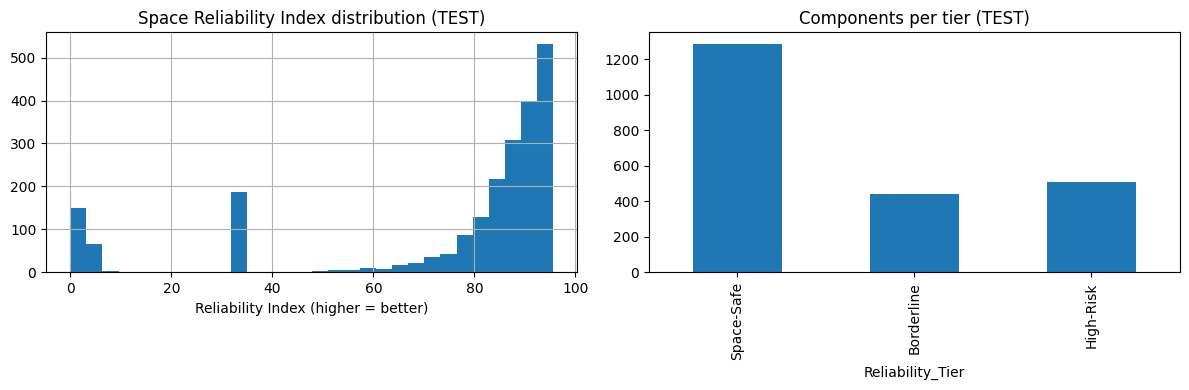

In [17]:
test_only = merged[merged['split'] == 'test']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
test_only['Space_Reliability_Index'].hist(bins=30, ax=axes[0])
axes[0].set_title('Space Reliability Index distribution (TEST)')
axes[0].set_xlabel('Reliability Index (higher = better)')

test_only['Reliability_Tier'].value_counts().reindex(['Space-Safe','Borderline','High-Risk']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Components per tier (TEST)')
plt.tight_layout()
plt.show()

## Final output table

In [18]:
final_cols = [
    'Component_ID', 'Batch_ID', 'Part_Type', 'Proxy_Stress', 'split',
    'Anomaly_Risk_Score', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Slope_Reject_Flag',
    'Space_Risk_Score', 'Space_Reliability_Index', 'Reliability_Tier',
    'Explainability_Reason', 'Label', 'Traditional_Test_Result',
]
final = merged[final_cols].sort_values('Space_Risk_Score', ascending=False)
final.head(10)

,Component_ID,Batch_ID,Part_Type,Proxy_Stress,split,Anomaly_Risk_Score,Predicted_Drift_Score,Uncertainty_Score,Slope_Reject_Flag,Space_Risk_Score,Space_Reliability_Index,Reliability_Tier,Explainability_Reason,Label,Traditional_Test_Result
8310,C2793,ISRO-SCL-250217-07,Voltage Regulator IC,Thermal-High,test,100.0,100.0,100.0,True,100.0,0.0,High-Risk,High-Risk. [SHAP] Predicted Leakage 168h drift...,Fail,Fail
2300,C4475,ISRO-SCL-250331-13,Op-Amp IC,Cycling-Medium,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
5237,C9468,ISRO-SCL-250407-14,Op-Amp IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
2930,C5562,ISRO-SCL-250512-19,Op-Amp IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
3280,C6136,ISRO-SCL-250331-13,Op-Amp IC,Cycling-Medium,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
5075,C9192,ISRO-SCL-250224-08,Digital Logic IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
7177,C7689,ISRO-SCL-250414-15,Voltage Regulator IC,Cycling-Medium,val,100.0,100.0,99.9,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
3968,C7295,ISRO-SCL-250428-17,Digital Logic IC,Thermal-High,train,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
6829,C5755,ISRO-SCL-250120-03,Op-Amp IC,Thermal-High,val,100.0,100.0,100.0,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail
4607,C8419,ISRO-SCL-250331-13,Op-Amp IC,Cycling-Medium,train,100.0,100.0,98.5,True,100.0,0.0,High-Risk,Not computed - SHAP explanations are bounded t...,Fail,Fail


In [19]:
final.to_csv('space_reliability_index.csv', index=False)
print(f'saved {len(final)} rows to space_reliability_index.csv (now tagged with a `split` column)')

saved 10000 rows to space_reliability_index.csv (now tagged with a `split` column)


## Score genuinely new components (live scoring - no 96h/168h/Traditional_Test_Result/Label)

Everything above runs on the full historical CSV (all four checkpoints + ground-truth Label),
which is correct for training/backtesting - it's how the tuned weights, tier cuts and
normalization bounds above were derived. But those are exactly the things a genuinely new
component doesn't have yet: it only has `0h`/`24h` readings, no `Traditional_Test_Result`
(the static check isn't final), no `Label` (nobody knows the outcome), and it isn't in
`component_split.csv` at all. `score_new_batch()` below is what the backend should actually
call for live scoring. It loads the three saved artifacts (`anomaly_pipeline.joblib`,
`drift_prediction_models.joblib`, `reliability_bundle.joblib`) plus the SHAP explainability
helpers already defined above, and returns a DataFrame with the exact same `final_cols` schema
as `space_reliability_index.csv` - `Label` and `Traditional_Test_Result` come back as `NA` and
`split` comes back as `'live'`, but every column your frontend/backend already reads is there.

In [20]:
anomaly_pipeline = joblib.load('anomaly_pipeline.joblib')   # from anomaly_detection.ipynb
reliability_bundle = joblib.load('reliability_bundle.joblib')

def score_new_batch(raw_df_new):
    """raw_df_new needs: Component_ID, Batch_ID, Part_Type, Proxy_Stress, Stress_Level,
    Timestamp_0h, Timestamp_24h, and {Leakage}_0h/_24h. Nothing about 96h,
    168h, Traditional_Test_Result, Label, or split is required.
    """
    d = raw_df_new.copy()

    # --- Module A: anomaly / lot-relative score (Traditional_Test_Result-optional pipeline) ---
    anomaly_new = anomaly_pipeline.predict(d)

    # --- Module B: drift prediction, using only 0h/24h (same feature pipeline as bundle) ---
    feature_cols_raw_n = bundle['feature_cols_raw']
    d['Timestamp_0h'] = pd.to_datetime(d['Timestamp_0h'], format='ISO8601')
    d['Timestamp_24h'] = pd.to_datetime(d['Timestamp_24h'], format='ISO8601')
    d['elapsed_24h'] = (d['Timestamp_24h'] - d['Timestamp_0h']).dt.total_seconds() / 3600
    d['elapsed_168h'] = bundle.get('nominal_elapsed_168h', 168.0)
    for col in feature_cols_raw_n:
        d.loc[d[col] < 0, col] = np.nan
    d.loc[:, feature_cols_raw_n] = bundle['imputer'].transform(d[feature_cols_raw_n])
    d['Leakage_slope'] = (d['Leakage_24h'] - d['Leakage_0h']) / d['elapsed_24h']
    feature_cols_num_n = bundle.get('feature_cols_num',
        feature_cols_raw_n + ['Stress_Level', 'elapsed_24h', 'Leakage_slope'])
    cat_cols_n = bundle.get('cat_cols', ['Proxy_Stress', 'Part_Type'])
    Xn = pd.get_dummies(d[feature_cols_num_n + cat_cols_n], columns=cat_cols_n)
    Xn = Xn.reindex(columns=bundle.get('train_columns', bundle['feature_columns']), fill_value=0)

    rf_p, gb_p = bundle['rf'].predict(Xn), bundle['gb'].predict(Xn)
    stacked_raw = bundle['meta_model'].predict(np.hstack([rf_p, gb_p]))
    lower_raw, upper_raw = bundle['quantile_lower'].predict(Xn), bundle['quantile_upper'].predict(Xn)
    lower_raw, upper_raw = np.minimum(lower_raw, upper_raw), np.maximum(lower_raw, upper_raw)

    def _reconstruct(raw):
        out = pd.DataFrame(index=d.index)
        out['Leakage_168h'] = np.expm1(raw[:, 1])
        return out

    point, lower, upper = _reconstruct(stacked_raw), _reconstruct(lower_raw), _reconstruct(upper_raw)
    d['Pred_Leakage_168h'] = point['Leakage_168h']
    d['Interval_Width_Leakage'] = (upper['Leakage_168h'] - lower['Leakage_168h']).clip(lower=0)

    safety_slope_n = bundle['safety_slope']
    slope_flag = pd.Series(False, index=d.index)
    for m in METRICS:
        rate = (d[f'Pred_{m}_168h'] - d[f'{m}_24h']) / (d['elapsed_168h'] - d['elapsed_24h'])
        slope_flag |= (rate.abs() > safety_slope_n[m])
    d['Slope_Reject_Flag'] = slope_flag

    pred_drift = ((d['Pred_Leakage_168h'] - d['Leakage_24h']) / d['Leakage_24h'].abs()).abs()
    d['Predicted_Drift_Score'] = (pred_drift.clip(upper=reliability_bundle['drift_score_bound'])
                                   / max(reliability_bundle['drift_score_bound'], 1e-9) * 100).clip(0, 100)

    iwb = reliability_bundle['iw_bounds']; disb = reliability_bundle['dis_bounds']
    aleatoric = (pd.Series(np.clip(d['Interval_Width_Leakage'] / max(iwb['Interval_Width_Leakage'], 1e-9), 0, 1.5))
                 .clip(0, 100) * 100 / 1.5)  # simplified single-metric width proxy for a live batch
    d['Uncertainty_Score'] = aleatoric.clip(0, 100).round(1)

    live = anomaly_new.merge(
        d[['Component_ID', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Proxy_Stress',
           'Slope_Reject_Flag']], on='Component_ID', how='inner')

    live['Space_Risk_Score'] = (reliability_bundle['weight_anomaly'] * live['Anomaly_Risk_Score']
        + reliability_bundle['weight_predicted_drift'] * live['Predicted_Drift_Score']
        + reliability_bundle['weight_uncertainty'] * live['Uncertainty_Score'])
    live['Space_Risk_Score'] = np.where(live['Absolute_Spec_Fail'] == 1,
        np.maximum(live['Space_Risk_Score'], reliability_bundle['absolute_fail_risk_floor']), live['Space_Risk_Score'])
    live['Space_Risk_Score'] = np.where(live['Slope_Reject_Flag'],
        np.maximum(live['Space_Risk_Score'], reliability_bundle['slope_reject_risk_floor']), live['Space_Risk_Score'])
    live['Space_Risk_Score'] = live['Space_Risk_Score'].clip(0, 100).round(1)
    live['Space_Reliability_Index'] = (100 - live['Space_Risk_Score']).round(1)

    def _tier(s):
        if s < reliability_bundle['risk_safe_max']: return 'Space-Safe'
        if s < reliability_bundle['risk_borderline_max']: return 'Borderline'
        return 'High-Risk'
    live['Reliability_Tier'] = live['Space_Risk_Score'].apply(_tier)
    live['split'] = 'live'
    live['Explainability_Reason'] = live['Reliability_Tier'] + '. Live estimate from 0h/24h data; '\
        'full explanation available once 96h/168h readings arrive.'

    # Always emit the exact same schema as space_reliability_index.csv
    for c in ['Label', 'Traditional_Test_Result']:
        if c not in live.columns:
            live[c] = pd.NA
    return live[final_cols].sort_values('Space_Risk_Score', ascending=False)

# --- demo: components that ONLY have 0h/24h, no future data at all ---
demo_live_raw = df.sample(10, random_state=11).drop(
    columns=[c for c in df.columns if c.endswith('_96h') or c.endswith('_168h')]
            + ['Traditional_Test_Result', 'Label', 'split', 'elapsed_168h'],
    errors='ignore',
)
print('demo_live_raw columns:', list(demo_live_raw.columns))
score_new_batch(demo_live_raw)


demo_live_raw columns: ['Component_ID', 'Batch_ID', 'Part_Type', 'Part_Family', 'Proxy_Stress', 'Stress_Level', 'Stress_Unit', 'Timestamp_0h', 'Timestamp_24h', 'Leakage_0h', 'Leakage_24h', 'elapsed_24h', 'Leakage_slope', 'Interval_Width_Leakage', 'Disagreement_Leakage', 'Predicted_Drift_Leakage', 'Predicted_Drift_Severity_raw', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Slope_Reject_Flag']


,Component_ID,Batch_ID,Part_Type,Proxy_Stress,split,Anomaly_Risk_Score,Predicted_Drift_Score,Uncertainty_Score,Slope_Reject_Flag,Space_Risk_Score,Space_Reliability_Index,Reliability_Tier,Explainability_Reason,Label,Traditional_Test_Result
6,C5630,ISRO-SCL-250407-14,Op-Amp IC,Thermal-High,live,51.8,94.507421,63.0,True,65.0,35.0,High-Risk,High-Risk. Live estimate from 0h/24h data; ful...,<NA>,<NA>
0,C3605,ISRO-SCL-250120-03,Op-Amp IC,Radiation-Low,live,16.0,27.937938,25.8,False,16.6,83.4,Borderline,Borderline. Live estimate from 0h/24h data; fu...,<NA>,<NA>
3,C6358,ISRO-SCL-250512-19,Op-Amp IC,Radiation-Low,live,10.4,28.136189,23.9,False,11.3,88.7,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
1,C6854,ISRO-SCL-250113-02,MOSFET,Cycling-Medium,live,10.7,6.106649,9.1,False,10.5,89.5,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
4,C6512,ISRO-SCL-250217-07,Voltage Regulator IC,Thermal-High,live,6.6,19.919966,22.2,False,7.3,92.7,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
5,C10322,ISRO-SCL-250324-12,Voltage Regulator IC,Thermal-High,live,6.0,15.742286,13.8,False,6.5,93.5,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
8,C4039,ISRO-SCL-250310-10,Voltage Regulator IC,Thermal-High,live,5.8,19.051654,16.2,False,6.4,93.6,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
7,C916,ISRO-SCL-250120-03,Op-Amp IC,Cycling-Medium,live,5.8,18.168904,18.2,False,6.4,93.6,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
2,C9190,ISRO-SCL-250519-20,Op-Amp IC,Thermal-High,live,6.1,9.218357,10.6,False,6.3,93.7,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
9,C2204,ISRO-SCL-250217-07,Voltage Regulator IC,Radiation-Low,live,4.4,18.311294,13.3,False,5.1,94.9,Space-Safe,Space-Safe. Live estimate from 0h/24h data; fu...,<NA>,<NA>
